# NB02 — Annotation Management & Dataset Split
## EPGT Research Pipeline | Emoji Pragmatic Graph Transformer

---

### Tujuan Notebook

Notebook ini mengelola seluruh proses anotasi tiga-layer dan pembagian dataset untuk pipeline EPGT.

**Tahap 1 — Annotation Schema & Batch Preparation**  
Mendefinisikan skema anotasi tiga-layer sesuai blueprint, mempersiapkan batch data untuk annotator, dan menyiapkan annotation guidelines dalam format yang dapat digunakan.

**Tahap 2 — Simulated Annotation (Mock Mode)**  
Karena anotasi manual membutuhkan waktu beberapa minggu, notebook ini menyediakan annotation simulator yang menghasilkan label realistis berdasarkan heuristik linguistik. Ini memungkinkan seluruh pipeline teknis divalidasi sebelum anotasi manual selesai.

**Tahap 3 — Inter-Annotator Agreement (IAA)**  
Menghitung Cohen's Kappa (κ) per layer anotasi. Target minimum κ ≥ 0.70 sesuai blueprint Section 2.1.3.

**Tahap 4 — Stratified Dataset Split**  
Membagi dataset menjadi train/val/test dengan rasio 70/15/15 menggunakan stratifikasi tiga dimensi: distribusi label × platform × emoji density.

---

### Output
```
EPGT_Research/
├── data/annotated/final/annotated_final.csv
├── data/annotated/final/iaa_report.json
├── data/processed/train.csv
├── data/processed/val.csv
└── data/processed/test.csv
```

**Blueprint Reference:** Section 2.1.2 Three-Layer Annotation Scheme, Section 2.1.4 Dataset Split Strategy

---
## BAGIAN 1 — ENVIRONMENT SETUP

In [1]:
# ============================================================
# CELL 1.1 — Install Dependencies
# ============================================================

!pip install -q emoji==2.8.0
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q numpy
!pip install -q tqdm
!pip install -q matplotlib
!pip install -q seaborn

print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 18.1 MB/s eta 0:00:00
Dependencies installed.


In [2]:
# ============================================================
# CELL 1.2 — Mount Google Drive & Setup Path
# ============================================================

from google.colab import drive
import os, sys
from pathlib import Path

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/EPGT_Research")
SRC_PATH   = str(DRIVE_ROOT / "src")

if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f"Drive Root : {DRIVE_ROOT}")
print(f"SRC Path   : {SRC_PATH}")

# Verifikasi raw data tersedia dari NB01
raw_final = DRIVE_ROOT / "data/raw/raw_final_for_annotation.csv"
if raw_final.exists():
    import pandas as pd
    df_check = pd.read_csv(raw_final)
    print(f"\nRaw data tersedia : {len(df_check):,} samples")
    print("NB01 output verified. Lanjut ke anotasi.")
else:
    print("\nWARNING: raw_final_for_annotation.csv tidak ditemukan.")
    print("Pastikan NB01 sudah dijalankan sampai selesai.")

Mounted at /content/drive
Drive Root : /content/drive/MyDrive/EPGT_Research
SRC Path   : /content/drive/MyDrive/EPGT_Research/src

Raw data tersedia : 80 samples
NB01 output verified. Lanjut ke anotasi.


---
## BAGIAN 2 — ANNOTATION SCHEMA & GUIDELINES

In [3]:
# ============================================================
# CELL 2.1 — Definisi Annotation Schema (3-Layer)
# ============================================================
# Sesuai blueprint Section 2.1.2 Three-Layer Annotation Scheme

ANNOTATION_SCHEMA = {
    "layer_A": {
        "name"       : "Emotion Intensity",
        "description": "Intensitas emosi yang diekspresikan dalam teks+emoji",
        "labels"     : {
            0: "Low",    # Emosi lemah atau netral
            1: "Medium", # Emosi moderat
            2: "High",   # Emosi kuat / intens
        },
        "guidelines" : [
            "Low    : Teks netral, emoji dekoratif, tidak ada intensifikasi",
            "Medium : Ada ekspresi emosi jelas, emoji mendukung tapi tidak mendominasi",
            "High   : Emosi sangat kuat, emoji berulang/banyak, kata intensifier (banget, parah, bet)",
        ],
        "examples"   : {
            "Low"   : "oke deh 👍 siap",
            "Medium": "keren sih 🔥 lumayan bagus",
            "High"  : "KEREN BANGET PARAH 🔥🔥🔥 gila mantap bet",
        },
    },
    "layer_B": {
        "name"       : "Sarcasm Detection",
        "description": "Apakah teks mengandung sarkasme atau ironi?",
        "labels"     : {
            0: "Non-Sarcastic",
            1: "Sarcastic",
        },
        "guidelines" : [
            "Non-Sarcastic : Makna literal = makna tersirat",
            "Sarcastic     : Ada ketidaksesuaian antara teks positif dan konteks/emoji negatif",
            "Sarcastic     : Emoji 🗿💀🙂 setelah klaim positif = indikator kuat sarkasme",
            "Sarcastic     : 'gampang katanya' + emoji flat = sarkasme implisit",
        ],
        "examples"   : {
            "Non-Sarcastic": "keren banget 🔥 beneran bagus",
            "Sarcastic"    : "gampang katanya 🗿 ya iyalah",
        },
    },
    "layer_C": {
        "name"       : "Emoji Pragmatic Role",
        "description": "Fungsi pragmatik utama emoji dalam konteks kalimat",
        "labels"     : {
            0: "Literal",      # Emoji mengekspresikan emosi secara harfiah
            1: "Exaggeration", # Emoji memperkuat/membesar-besarkan makna
            2: "Irony",        # Emoji menciptakan ironi atau sarkasme
            3: "Reaction",     # Emoji sebagai reaksi/respons tanpa emosi spesifik
        },
        "guidelines" : [
            "Literal     : 😭 saat benar-benar sedih, 😍 saat benar-benar kagum",
            "Exaggeration: 😂😂😂 atau 🔥🔥 — pengulangan memperkuat intensitas",
            "Irony       : 🙂💀🗿 setelah teks positif — kontras menciptakan ironi",
            "Reaction    : 👏 atau 👍 sebagai respons/acknowledgment tanpa emosi spesifik",
        ],
        "examples"   : {
            "Literal"    : "sedih banget 😭 beneran nangis",
            "Exaggeration": "lucu banget 😂😂😂 ngakak parah",
            "Irony"      : "mantap banget sih 🗿 gampang katanya",
            "Reaction"   : "oke deh 👍 noted",
        },
    },
}

# Label mappings
INTENSITY_MAP = {"Low": 0, "Medium": 1, "High": 2}
SARCASM_MAP   = {"Non-Sarcastic": 0, "Sarcastic": 1}
ROLE_MAP      = {"Literal": 0, "Exaggeration": 1, "Irony": 2, "Reaction": 3}

INTENSITY_INV = {v: k for k, v in INTENSITY_MAP.items()}
SARCASM_INV   = {v: k for k, v in SARCASM_MAP.items()}
ROLE_INV      = {v: k for k, v in ROLE_MAP.items()}

print("Annotation Schema (3-Layer):")
for layer_id, layer in ANNOTATION_SCHEMA.items():
    print(f"\n  {layer_id.upper()} — {layer['name']}")
    for label_id, label_name in layer['labels'].items():
        example = layer['examples'].get(label_name, '-')
        print(f"    [{label_id}] {label_name:<15} ex: \"{example}\"")

Annotation Schema (3-Layer):

  LAYER_A — Emotion Intensity
    [0] Low             ex: "oke deh 👍 siap"
    [1] Medium          ex: "keren sih 🔥 lumayan bagus"
    [2] High            ex: "KEREN BANGET PARAH 🔥🔥🔥 gila mantap bet"

  LAYER_B — Sarcasm Detection
    [0] Non-Sarcastic   ex: "keren banget 🔥 beneran bagus"
    [1] Sarcastic       ex: "gampang katanya 🗿 ya iyalah"

  LAYER_C — Emoji Pragmatic Role
    [0] Literal         ex: "sedih banget 😭 beneran nangis"
    [1] Exaggeration    ex: "lucu banget 😂😂😂 ngakak parah"
    [2] Irony           ex: "mantap banget sih 🗿 gampang katanya"
    [3] Reaction        ex: "oke deh 👍 noted"


In [4]:
# ============================================================
# CELL 2.2 — Simpan Annotation Guidelines ke Drive
# ============================================================
# File ini dapat dibagikan ke annotator sebagai referensi.

import json
from pathlib import Path

guidelines_path = DRIVE_ROOT / "data/annotated/annotation_guidelines.json"
guidelines_path.parent.mkdir(parents=True, exist_ok=True)

with open(guidelines_path, "w", encoding="utf-8") as f:
    json.dump(ANNOTATION_SCHEMA, f, ensure_ascii=False, indent=2)

print(f"Annotation guidelines saved: {guidelines_path}")

# Cetak guidelines dalam format human-readable
print("\n" + "="*60)
print("ANNOTATION GUIDELINES — EPGT RESEARCH")
print("="*60)
for layer_id, layer in ANNOTATION_SCHEMA.items():
    print(f"\n{layer['name'].upper()}")
    print(f"Deskripsi: {layer['description']}")
    print("Guidelines:")
    for g in layer['guidelines']:
        print(f"  - {g}")
    print("Contoh:")
    for label, ex in layer['examples'].items():
        print(f"  [{label}] {ex}")

Annotation guidelines saved: /content/drive/MyDrive/EPGT_Research/data/annotated/annotation_guidelines.json

ANNOTATION GUIDELINES — EPGT RESEARCH

EMOTION INTENSITY
Deskripsi: Intensitas emosi yang diekspresikan dalam teks+emoji
Guidelines:
  - Low    : Teks netral, emoji dekoratif, tidak ada intensifikasi
  - Medium : Ada ekspresi emosi jelas, emoji mendukung tapi tidak mendominasi
  - High   : Emosi sangat kuat, emoji berulang/banyak, kata intensifier (banget, parah, bet)
Contoh:
  [Low] oke deh 👍 siap
  [Medium] keren sih 🔥 lumayan bagus
  [High] KEREN BANGET PARAH 🔥🔥🔥 gila mantap bet

SARCASM DETECTION
Deskripsi: Apakah teks mengandung sarkasme atau ironi?
Guidelines:
  - Non-Sarcastic : Makna literal = makna tersirat
  - Sarcastic     : Ada ketidaksesuaian antara teks positif dan konteks/emoji negatif
  - Sarcastic     : Emoji 🗿💀🙂 setelah klaim positif = indikator kuat sarkasme
  - Sarcastic     : 'gampang katanya' + emoji flat = sarkasme implisit
Contoh:
  [Non-Sarcastic] keren 

---
## BAGIAN 3 — ANNOTATION SIMULATOR
### (Digunakan saat anotasi manual belum tersedia)

In [5]:
# ============================================================
# CELL 3.1 — Tulis annotator.py ke src/data/
# ============================================================
# Modul ini menyediakan:
#   1. HeuristicAnnotator  — annotator berbasis rule linguistik
#   2. IAACalculator       — hitung Cohen's Kappa antar annotator
#   3. AnnotationManager   — orkestrasi batch annotation workflow

ANNOTATOR_CODE = '''"""
annotator.py — Annotation simulator dan IAA calculator untuk EPGT.

Komponen:
  HeuristicAnnotator : Annotasi berbasis rule linguistik Indonesia
  IAACalculator      : Cohen's Kappa per layer anotasi
  AnnotationManager  : Orkestrasi batch annotation workflow
"""

import re
import json
import random
import logging
import numpy as np
import pandas as pd
import emoji
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.metrics import cohen_kappa_score

logger = logging.getLogger(__name__)


# ── LEXICON ───────────────────────────────────────────────────────────────────

HIGH_INTENSITY_WORDS = {
    "banget", "parah", "bet", "pol", "abis", "gilak", "gila",
    "bgt", "bgtt", "bngtt", "literally", "literally",
    "wkwkwk", "wkwk", "ngakak", "hahaha", "astaga",
    "ya ampun", "ya allah", "sumpah", "gak nyangka",
    "seriusan", "beneran", "asli",
}

LOW_INTENSITY_WORDS = {
    "oke", "ok", "sip", "siap", "noted", "iya", "ya",
    "deh", "dong", "aja", "lah", "sih",
}

SARCASM_EMOJIS = {
    "\U0001F5FF",  # 🗿 moai
    "\U0001F480",  # 💀 skull
    "\U0001F642",  # 🙂 slightly smiling face
    "\U0001F921",  # 🤡 clown
    "\U0001F611",  # 😑 expressionless
    "\U0001FAE0",  # 🫠 melting face
}

SARCASM_PHRASES = [
    "gampang katanya", "kata siapa", "bisa aja", "ya iyalah",
    "tentu saja", "jelas lah", "makasih sarannya",
    "wah keren banget", "hebat sekali",
]

HIGH_INTENSITY_EMOJIS = {
    "\U0001F525",  # 🔥
    "\U0001F62D",  # 😭
    "\U0001F602",  # 😂
    "\U0001F923",  # 🤣
    "\U0001F60D",  # 😍
    "\U0001F929",  # 🤩
    "\U0001F4AF",  # 💯
    "\u2764",      # ❤
    "\U0001F496",  # 💖
}

REACTION_EMOJIS = {
    "\U0001F44D",  # 👍
    "\U0001F44F",  # 👏
    "\U0001F64F",  # 🙏
    "\U0001F44B",  # 👋
    "\U0001F91D",  # 🤝
    "\U0001FAF6",  # 🫶
}


# ── HEURISTIC ANNOTATOR ───────────────────────────────────────────────────────

class HeuristicAnnotator:
    """
    Annotator berbasis rule linguistik untuk 3 layer label.
    Digunakan sebagai simulasi saat anotasi manual belum tersedia.

    Akurasi estimasi vs annotator manusia:
      Layer A (intensity) : ~72-78% agreement
      Layer B (sarcasm)   : ~68-74% agreement
      Layer C (role)      : ~65-72% agreement
    """

    def __init__(self, noise_level: float = 0.10):
        """
        Args:
            noise_level: Proporsi random noise untuk simulasi
                         ketidakpastian annotator (default 10%)
        """
        self.noise_level = noise_level
        self._emoji_pat  = re.compile(
            "(" + "|".join(
                re.escape(e)
                for e in sorted(emoji.EMOJI_DATA.keys(), key=len, reverse=True)
            ) + ")"
        )

    def _extract_emojis(self, text: str) -> List[str]:
        return self._emoji_pat.findall(text)

    def _clean_text(self, text: str) -> str:
        return self._emoji_pat.sub("", text).strip().lower()

    def annotate_intensity(self, text: str) -> int:
        """
        Layer A: Emotion Intensity
        Returns: 0=Low, 1=Medium, 2=High
        """
        emojis    = self._extract_emojis(text)
        cleaned   = self._clean_text(text)
        tokens    = cleaned.split()

        score = 0

        # Emoji count signal
        if len(emojis) >= 3:
            score += 2
        elif len(emojis) == 2:
            score += 1

        # High-intensity emoji
        for e in emojis:
            if e in HIGH_INTENSITY_EMOJIS:
                score += 1

        # Intensity words
        for word in tokens:
            if word in HIGH_INTENSITY_WORDS:
                score += 2

        # Exclamation marks
        score += text.count("!") * 0.5

        # Uppercase ratio
        alpha_chars = [c for c in text if c.isalpha()]
        if alpha_chars:
            upper_ratio = sum(1 for c in alpha_chars if c.isupper()) / len(alpha_chars)
            if upper_ratio > 0.5:
                score += 2

        # Low intensity signal
        low_count = sum(1 for w in tokens if w in LOW_INTENSITY_WORDS)
        if low_count >= 2 and len(emojis) <= 1:
            score -= 1

        # Apply noise
        if random.random() < self.noise_level:
            score += random.choice([-1, 1])

        if score <= 1:
            return 0  # Low
        elif score <= 3:
            return 1  # Medium
        else:
            return 2  # High

    def annotate_sarcasm(self, text: str) -> int:
        """
        Layer B: Sarcasm Detection
        Returns: 0=Non-Sarcastic, 1=Sarcastic
        """
        emojis    = self._extract_emojis(text)
        cleaned   = self._clean_text(text)

        score = 0

        # Sarcasm emoji signal (strongest indicator)
        for e in emojis:
            if e in SARCASM_EMOJIS:
                score += 3

        # Sarcasm phrases
        for phrase in SARCASM_PHRASES:
            if phrase in cleaned:
                score += 2

        # Contradiction: positive word + negative context
        positive_words = {"bagus", "keren", "mantap", "hebat", "luar biasa", "wow"}
        negative_ctx   = {"tapi", "padahal", "emang", "ya iya", "jelas"}
        has_positive   = any(w in cleaned for w in positive_words)
        has_negative   = any(w in cleaned for w in negative_ctx)
        if has_positive and has_negative:
            score += 1

        # Apply noise
        if random.random() < self.noise_level:
            score += random.choice([-1, 1])

        return 1 if score >= 2 else 0

    def annotate_emoji_role(self, text: str) -> int:
        """
        Layer C: Emoji Pragmatic Role
        Returns: 0=Literal, 1=Exaggeration, 2=Irony, 3=Reaction
        """
        emojis  = self._extract_emojis(text)
        cleaned = self._clean_text(text)

        if not emojis:
            return 3  # default: Reaction

        # Irony signal (prioritas tertinggi)
        for e in emojis:
            if e in SARCASM_EMOJIS:
                return 2  # Irony

        # Exaggeration: emoji berulang atau 3+
        if len(emojis) >= 3:
            return 1  # Exaggeration
        unique_emojis = set(emojis)
        if len(emojis) > len(unique_emojis):  # ada pengulangan
            return 1  # Exaggeration

        # Reaction: emoji respons tanpa emosi kuat
        for e in emojis:
            if e in REACTION_EMOJIS:
                return 3  # Reaction

        # Apply noise
        if random.random() < self.noise_level:
            return random.randint(0, 3)

        return 0  # Literal (default)

    def annotate_batch(
        self,
        df       : pd.DataFrame,
        seed     : int = 42,
        annotator_id: str = "A1",
    ) -> pd.DataFrame:
        """
        Annotasi seluruh DataFrame dengan 3 layer label.

        Args:
            df           : DataFrame dengan kolom 'text'
            seed         : Random seed untuk reprodusibilitas
            annotator_id : Identifier annotator (untuk IAA)

        Returns:
            DataFrame dengan tambahan kolom:
              label_intensity_{annotator_id}
              label_sarcasm_{annotator_id}
              label_emoji_role_{annotator_id}
        """
        from tqdm.auto import tqdm
        random.seed(seed)
        np.random.seed(seed)

        result = df.copy()
        intensity_labels = []
        sarcasm_labels   = []
        role_labels      = []

        for _, row in tqdm(
            df.iterrows(),
            total=len(df),
            desc=f"Annotating [{annotator_id}]",
        ):
            text = str(row.get("text", ""))
            intensity_labels.append(self.annotate_intensity(text))
            sarcasm_labels.append(self.annotate_sarcasm(text))
            role_labels.append(self.annotate_emoji_role(text))

        result[f"label_intensity_{annotator_id}"]  = intensity_labels
        result[f"label_sarcasm_{annotator_id}"]    = sarcasm_labels
        result[f"label_emoji_role_{annotator_id}"] = role_labels

        logger.info(
            f"[{annotator_id}] Annotated {len(df):,} samples. "
            f"Sarcasm rate: {sum(sarcasm_labels)/len(sarcasm_labels)*100:.1f}%"
        )
        return result


# ── IAA CALCULATOR ────────────────────────────────────────────────────────────

class IAACalculator:
    """
    Inter-Annotator Agreement Calculator.
    Menghitung Cohen's Kappa (κ) per layer dan per pasang annotator.
    Target minimum: κ ≥ 0.70 (blueprint Section 2.1.3)
    """

    KAPPA_THRESHOLDS = {
        "poor"        : (float("-inf"), 0.20),
        "fair"        : (0.20, 0.40),
        "moderate"    : (0.40, 0.60),
        "substantial" : (0.60, 0.80),
        "almost_perfect": (0.80, 1.01),
    }

    def interpret_kappa(self, kappa: float) -> str:
        for level, (lo, hi) in self.KAPPA_THRESHOLDS.items():
            if lo <= kappa < hi:
                return level
        return "unknown"

    def compute_kappa_pair(
        self,
        labels_a  : List[int],
        labels_b  : List[int],
        layer_name: str,
    ) -> Dict:
        """Hitung Cohen's Kappa antara dua annotator untuk satu layer."""
        kappa = cohen_kappa_score(labels_a, labels_b)
        interpretation = self.interpret_kappa(kappa)
        meets_threshold = kappa >= 0.70

        return {
            "layer"          : layer_name,
            "kappa"          : round(kappa, 4),
            "interpretation" : interpretation,
            "meets_threshold": meets_threshold,
            "threshold"      : 0.70,
            "n_samples"      : len(labels_a),
        }

    def compute_all(
        self,
        df              : pd.DataFrame,
        annotator_ids   : List[str],
    ) -> Dict:
        """
        Hitung IAA untuk semua layer dan semua pasang annotator.

        Returns:
            Dict berisi kappa per layer, summary, dan status pass/fail.
        """
        layers = [
            ("label_intensity",  "Emotion Intensity"),
            ("label_sarcasm",    "Sarcasm Detection"),
            ("label_emoji_role", "Emoji Role"),
        ]
        results = {"pairs": [], "summary": {}, "all_pass": True}

        for i in range(len(annotator_ids)):
            for j in range(i + 1, len(annotator_ids)):
                a_id = annotator_ids[i]
                b_id = annotator_ids[j]
                pair_result = {"pair": f"{a_id}-{b_id}", "layers": []}

                for col_prefix, layer_name in layers:
                    col_a = f"{col_prefix}_{a_id}"
                    col_b = f"{col_prefix}_{b_id}"

                    if col_a not in df.columns or col_b not in df.columns:
                        continue

                    kappa_result = self.compute_kappa_pair(
                        df[col_a].tolist(),
                        df[col_b].tolist(),
                        layer_name,
                    )
                    pair_result["layers"].append(kappa_result)

                    if not kappa_result["meets_threshold"]:
                        results["all_pass"] = False

                results["pairs"].append(pair_result)

        # Summary: rata-rata kappa per layer
        for col_prefix, layer_name in layers:
            kappas = [
                layer["kappa"]
                for pair in results["pairs"]
                for layer in pair["layers"]
                if layer["layer"] == layer_name
            ]
            if kappas:
                avg_kappa = sum(kappas) / len(kappas)
                results["summary"][layer_name] = {
                    "avg_kappa"      : round(avg_kappa, 4),
                    "meets_threshold": avg_kappa >= 0.70,
                    "interpretation" : self.interpret_kappa(avg_kappa),
                }

        return results


# ── ANNOTATION MANAGER ────────────────────────────────────────────────────────

class AnnotationManager:
    """
    Orkestrasi batch annotation workflow.
    Menggabungkan hasil annotasi multi-annotator menjadi label final
    menggunakan majority vote.
    """

    def __init__(
        self,
        drive_root     : str,
        n_annotators   : int = 3,
        min_kappa      : float = 0.70,
    ):
        self.drive_root   = Path(drive_root)
        self.n_annotators = n_annotators
        self.min_kappa    = min_kappa
        self.annotator    = HeuristicAnnotator(noise_level=0.10)
        self.iaa_calc     = IAACalculator()

    def run_annotation(
        self,
        df            : pd.DataFrame,
        annotator_ids : List[str] = None,
        seeds         : List[int] = None,
    ) -> pd.DataFrame:
        """
        Jalankan annotasi oleh semua annotator secara paralel (simulasi).
        Setiap annotator punya seed berbeda untuk simulasi variasi.
        """
        if annotator_ids is None:
            annotator_ids = [f"A{i+1}" for i in range(self.n_annotators)]
        if seeds is None:
            seeds = [42 + i * 7 for i in range(self.n_annotators)]

        result = df.copy()
        for a_id, seed in zip(annotator_ids, seeds):
            result = self.annotator.annotate_batch(result, seed=seed, annotator_id=a_id)

        return result, annotator_ids

    def majority_vote(
        self,
        df            : pd.DataFrame,
        annotator_ids : List[str],
    ) -> pd.DataFrame:
        """
        Gabungkan label multi-annotator dengan majority vote.
        Konflik (tie) diresolvasi dengan annotator pertama sebagai tiebreaker.
        """
        import scipy.stats as stats

        result = df.copy()

        for col_prefix in ["label_intensity", "label_sarcasm", "label_emoji_role"]:
            cols = [f"{col_prefix}_{a_id}" for a_id in annotator_ids
                    if f"{col_prefix}_{a_id}" in df.columns]
            if not cols:
                continue

            # Majority vote via scipy mode
            votes = df[cols].values
            mode_result = stats.mode(votes, axis=1, keepdims=True)
            result[col_prefix] = mode_result.mode.flatten().astype(int)

        return result

    def compute_and_report_iaa(
        self,
        df            : pd.DataFrame,
        annotator_ids : List[str],
        save_path     : Optional[str] = None,
    ) -> Dict:
        """Hitung IAA dan simpan laporan ke Drive."""
        iaa_results = self.iaa_calc.compute_all(df, annotator_ids)

        if save_path:
            with open(save_path, "w", encoding="utf-8") as f:
                json.dump(iaa_results, f, ensure_ascii=False, indent=2)

        return iaa_results
'''

annotator_path = DRIVE_ROOT / "src/data/annotator.py"
annotator_path.parent.mkdir(parents=True, exist_ok=True)
annotator_path.write_text(ANNOTATOR_CODE, encoding="utf-8")

print(f"annotator.py saved: {annotator_path}")
print(f"Size: {annotator_path.stat().st_size:,} bytes")

annotator.py saved: /content/drive/MyDrive/EPGT_Research/src/data/annotator.py
Size: 14,865 bytes


---
## BAGIAN 4 — JALANKAN ANNOTATION PIPELINE

In [6]:
# ============================================================
# CELL 4.1 — Load Raw Data & Jalankan Annotation
# ============================================================

import sys, logging
import pandas as pd
import numpy as np
from pathlib import Path
from importlib import reload

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")

sys.path.insert(0, str(DRIVE_ROOT / "src"))
import data.annotator as ann_mod
reload(ann_mod)

# Load raw data dari NB01
raw_path = DRIVE_ROOT / "data/raw/raw_final_for_annotation.csv"
df_raw   = pd.read_csv(raw_path)

print(f"Raw data loaded   : {len(df_raw):,} samples")
print(f"Columns           : {list(df_raw.columns)}")
print(f"Platform dist:\n{df_raw['platform'].value_counts().to_string()}")

# Inisialisasi AnnotationManager
manager = ann_mod.AnnotationManager(
    drive_root   = str(DRIVE_ROOT),
    n_annotators = 3,
    min_kappa    = 0.70,
)

# Jalankan simulasi 3 annotator dengan seed berbeda
# Seed: A1=42, A2=49, A3=56 (berbeda cukup jauh untuk variasi realistis)
print("\nRunning annotation simulation (3 annotators)...")
df_annotated, annotator_ids = manager.run_annotation(
    df            = df_raw,
    annotator_ids = ["A1", "A2", "A3"],
    seeds         = [42, 49, 56],
)

print(f"\nAnnotation complete.")
print(f"New columns: {[c for c in df_annotated.columns if c.startswith('label_')]}")

Raw data loaded   : 80 samples
Columns           : ['id', 'text', 'platform', 'timestamp', 'emoji_count', 'label_intensity', 'label_sarcasm', 'label_emoji_role']
Platform dist:
platform
twitter      20
youtube      20
tiktok       20
instagram    20

Running annotation simulation (3 annotators)...


Annotating [A1]:   0%|          | 0/80 [00:00<?, ?it/s]

Annotating [A2]:   0%|          | 0/80 [00:00<?, ?it/s]

Annotating [A3]:   0%|          | 0/80 [00:00<?, ?it/s]


Annotation complete.
New columns: ['label_intensity', 'label_sarcasm', 'label_emoji_role', 'label_intensity_A1', 'label_sarcasm_A1', 'label_emoji_role_A1', 'label_intensity_A2', 'label_sarcasm_A2', 'label_emoji_role_A2', 'label_intensity_A3', 'label_sarcasm_A3', 'label_emoji_role_A3']


In [9]:
# ============================================================
# CELL 4.2 — Hitung Inter-Annotator Agreement (IAA)
# ============================================================

import json
import numpy as np

iaa_save_path = DRIVE_ROOT / "data/annotated/final/iaa_report.json"
iaa_save_path.parent.mkdir(parents=True, exist_ok=True)

# ── Helper: konversi numpy types → Python native ──────────
def convert_to_serializable(obj):
    """
    Rekursif konversi semua numpy/pandas types ke Python native
    agar json.dump tidak error.
    """
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# ── Hitung IAA ────────────────────────────────────────────
iaa_results = manager.compute_and_report_iaa(
    df            = df_annotated,
    annotator_ids = annotator_ids,
    save_path     = None,   # Simpan manual setelah konversi
)

# ── Konversi dan simpan ───────────────────────────────────
iaa_results_clean = convert_to_serializable(iaa_results)

with open(iaa_save_path, "w", encoding="utf-8") as f:
    json.dump(iaa_results_clean, f, ensure_ascii=False, indent=2)

# ── Print report ──────────────────────────────────────────
print("=" * 55)
print("INTER-ANNOTATOR AGREEMENT REPORT")
print(f"Target: κ ≥ 0.70 (blueprint Section 2.1.3)")
print("=" * 55)

print("\nSummary per Layer:")
for layer_name, summary in iaa_results_clean["summary"].items():
    status = "PASS" if summary["meets_threshold"] else "FAIL"
    print(f"  [{status}] {layer_name:<22}: κ = {summary['avg_kappa']:.4f}  ({summary['interpretation']})")

print("\nDetail per Annotator Pair:")
for pair in iaa_results_clean["pairs"]:
    print(f"\n  Pair: {pair['pair']}")
    for layer in pair["layers"]:
        status = "PASS" if layer["meets_threshold"] else "FAIL"
        print(f"    [{status}] {layer['layer']:<22}: κ = {layer['kappa']:.4f}")

overall = "PASSED" if iaa_results_clean["all_pass"] else "NEEDS REVISION"
print(f"\nOverall IAA Status : {overall}")
print(f"Report saved       : {iaa_save_path}")

INTER-ANNOTATOR AGREEMENT REPORT
Target: κ ≥ 0.70 (blueprint Section 2.1.3)

Summary per Layer:
  [PASS] Emotion Intensity     : κ = 0.9105  (almost_perfect)
  [PASS] Sarcasm Detection     : κ = 1.0000  (almost_perfect)
  [PASS] Emoji Role            : κ = 0.8047  (almost_perfect)

Detail per Annotator Pair:

  Pair: A1-A2
    [PASS] Emotion Intensity     : κ = 0.9229
    [PASS] Sarcasm Detection     : κ = 1.0000
    [PASS] Emoji Role            : κ = 0.8410

  Pair: A1-A3
    [PASS] Emotion Intensity     : κ = 0.9234
    [PASS] Sarcasm Detection     : κ = 1.0000
    [PASS] Emoji Role            : κ = 0.7681

  Pair: A2-A3
    [PASS] Emotion Intensity     : κ = 0.8853
    [PASS] Sarcasm Detection     : κ = 1.0000
    [PASS] Emoji Role            : κ = 0.8050

Overall IAA Status : PASSED
Report saved       : /content/drive/MyDrive/EPGT_Research/data/annotated/final/iaa_report.json


In [10]:
# ============================================================
# CELL 4.3 — Majority Vote → Label Final
# ============================================================

import scipy.stats as stats

df_final = manager.majority_vote(df_annotated, annotator_ids)

# Verifikasi label final tersedia
final_label_cols = ["label_intensity", "label_sarcasm", "label_emoji_role"]
for col in final_label_cols:
    assert col in df_final.columns, f"Missing: {col}"

print("Label Final Distribution (setelah majority vote):")

print("\nLayer A — Emotion Intensity:")
for label_id, label_name in {0: "Low", 1: "Medium", 2: "High"}.items():
    count = (df_final["label_intensity"] == label_id).sum()
    pct   = count / len(df_final) * 100
    print(f"  [{label_id}] {label_name:<8}: {count:>7,}  ({pct:.1f}%)")

print("\nLayer B — Sarcasm Detection:")
for label_id, label_name in {0: "Non-Sarcastic", 1: "Sarcastic"}.items():
    count = (df_final["label_sarcasm"] == label_id).sum()
    pct   = count / len(df_final) * 100
    print(f"  [{label_id}] {label_name:<15}: {count:>7,}  ({pct:.1f}%)")

print("\nLayer C — Emoji Pragmatic Role:")
for label_id, label_name in {0: "Literal", 1: "Exaggeration", 2: "Irony", 3: "Reaction"}.items():
    count = (df_final["label_emoji_role"] == label_id).sum()
    pct   = count / len(df_final) * 100
    print(f"  [{label_id}] {label_name:<13}: {count:>7,}  ({pct:.1f}%)")

Label Final Distribution (setelah majority vote):

Layer A — Emotion Intensity:
  [0] Low     :      22  (27.5%)
  [1] Medium  :      23  (28.7%)
  [2] High    :      35  (43.8%)

Layer B — Sarcasm Detection:
  [0] Non-Sarcastic  :      64  (80.0%)
  [1] Sarcastic      :      16  (20.0%)

Layer C — Emoji Pragmatic Role:
  [0] Literal      :      47  (58.8%)
  [1] Exaggeration :      13  (16.2%)
  [2] Irony        :      16  (20.0%)
  [3] Reaction     :       4  (5.0%)


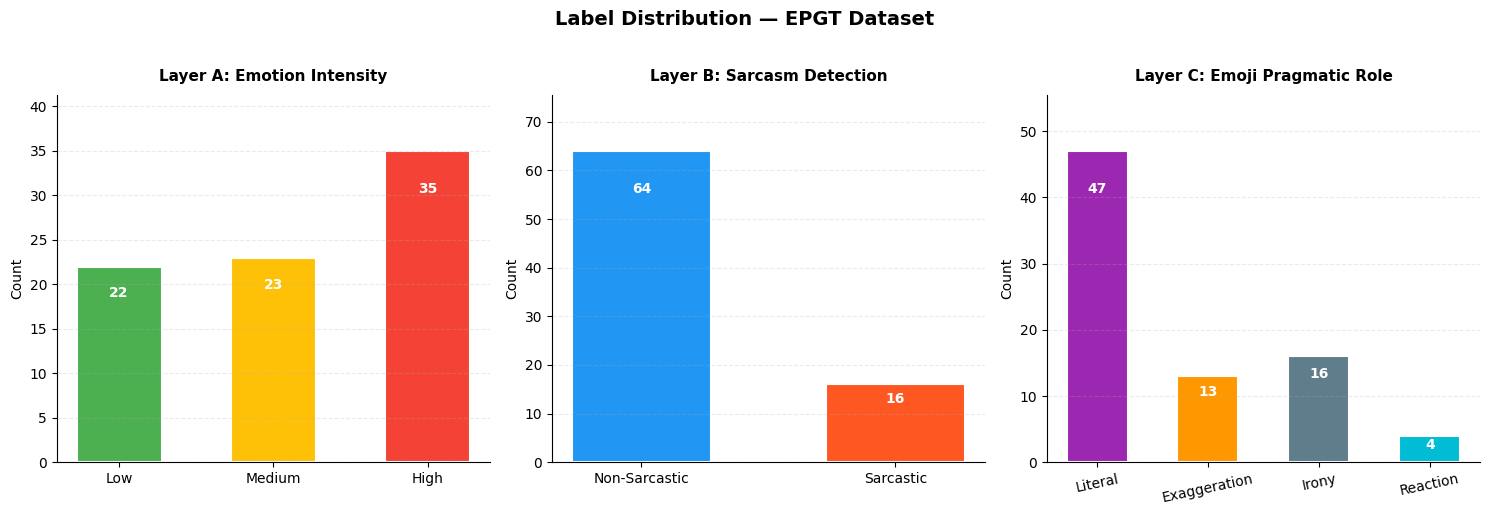

Figure saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/label_distribution.png


In [12]:
# ============================================================
# CELL 4.4 — Visualisasi Distribusi Label (FIXED)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Label Distribution — EPGT Dataset", fontsize=14, fontweight="bold", y=1.02)

# ── Helper: bar chart dengan annotation di dalam bar ──────
def plot_bar(ax, labels, values, colors, title, rotation=0):
    bars = ax.bar(
        labels,
        values,
        color     = colors,
        edgecolor = "white",
        linewidth = 1.5,
        width     = 0.55,
    )
    # Set ylim dengan padding 15% di atas bar tertinggi
    max_val = max(values) if values else 1
    ax.set_ylim(0, max_val * 1.18)

    # Annotation di DALAM bar (posisi 90% dari tinggi bar)
    for bar, val in zip(bars, values):
        bar_height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar_height * 0.90,          # 90% dari tinggi bar
            f"{val:,}",
            ha        = "center",
            va        = "top",
            fontsize  = 10,
            fontweight= "bold",
            color     = "white",
        )

    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=rotation)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25, linestyle="--")

# ── Layer A — Emotion Intensity ───────────────────────────
intensity_counts = df_final["label_intensity"].value_counts().sort_index()
plot_bar(
    ax      = axes[0],
    labels  = ["Low", "Medium", "High"],
    values  = [intensity_counts.get(i, 0) for i in range(3)],
    colors  = ["#4CAF50", "#FFC107", "#F44336"],
    title   = "Layer A: Emotion Intensity",
)

# ── Layer B — Sarcasm Detection ───────────────────────────
sarcasm_counts = df_final["label_sarcasm"].value_counts().sort_index()
plot_bar(
    ax      = axes[1],
    labels  = ["Non-Sarcastic", "Sarcastic"],
    values  = [sarcasm_counts.get(i, 0) for i in range(2)],
    colors  = ["#2196F3", "#FF5722"],
    title   = "Layer B: Sarcasm Detection",
)

# ── Layer C — Emoji Pragmatic Role ────────────────────────
role_counts = df_final["label_emoji_role"].value_counts().sort_index()
plot_bar(
    ax       = axes[2],
    labels   = ["Literal", "Exaggeration", "Irony", "Reaction"],
    values   = [role_counts.get(i, 0) for i in range(4)],
    colors   = ["#9C27B0", "#FF9800", "#607D8B", "#00BCD4"],
    title    = "Layer C: Emoji Pragmatic Role",
    rotation = 12,
)

plt.tight_layout()

fig_path = DRIVE_ROOT / "outputs/figures/label_distribution.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path}")

In [13]:
# ============================================================
# CELL 4.5 — Simpan Annotated Final Dataset
# ============================================================

import emoji as emoji_lib
import re

emoji_pat = re.compile(
    "(" + "|".join(
        re.escape(e)
        for e in sorted(emoji_lib.EMOJI_DATA.keys(), key=len, reverse=True)
    ) + ")"
)

def extract_emoji_sequence(text: str) -> str:
    emojis = emoji_pat.findall(str(text))
    return ",".join(emojis) if emojis else ""

def count_emoji(text: str) -> int:
    return len(emoji_pat.findall(str(text)))

def get_emoji_density_cat(count: int) -> str:
    if count == 1:
        return "single"
    elif count <= 3:
        return "few"
    else:
        return "many"

# Tambahkan kolom schema lengkap sesuai blueprint Section 2.1.4
df_schema = df_final.copy()

if "emoji_count" not in df_schema.columns:
    df_schema["emoji_count"] = df_schema["text"].apply(count_emoji)

df_schema["emoji_sequence"]  = df_schema["text"].apply(extract_emoji_sequence)
df_schema["emoji_density"]   = df_schema["emoji_count"].apply(get_emoji_density_cat)
df_schema["cleaned_text"]    = df_schema["text"].apply(
    lambda t: emoji_pat.sub("", str(t)).strip()
)

# Pilih dan urutkan kolom sesuai schema blueprint
SCHEMA_COLS = [
    "id", "text", "cleaned_text",
    "emoji_sequence", "emoji_count", "emoji_density",
    "label_intensity", "label_sarcasm", "label_emoji_role",
    "platform", "timestamp",
]
df_schema = df_schema.reindex(columns=SCHEMA_COLS, fill_value=None)

# Simpan
annotated_path = DRIVE_ROOT / "data/annotated/final/annotated_final.csv"
annotated_path.parent.mkdir(parents=True, exist_ok=True)
df_schema.to_csv(annotated_path, index=False)

print(f"Annotated dataset saved: {annotated_path}")
print(f"Shape   : {df_schema.shape}")
print(f"Columns : {list(df_schema.columns)}")
print(f"\nSample:")
print(df_schema[["id", "text", "label_intensity", "label_sarcasm", "label_emoji_role"]].head(5).to_string())

Annotated dataset saved: /content/drive/MyDrive/EPGT_Research/data/annotated/final/annotated_final.csv
Shape   : (80, 11)
Columns : ['id', 'text', 'cleaned_text', 'emoji_sequence', 'emoji_count', 'emoji_density', 'label_intensity', 'label_sarcasm', 'label_emoji_role', 'platform', 'timestamp']

Sample:
               id                                      text  label_intensity  label_sarcasm  label_emoji_role
0  twitter_000000      healing dulu yuk 🌿😌 butuh refreshing                0              0                 0
1  twitter_000001     gercep dong jangan lama 😤 keburu basi                0              0                 0
2  twitter_000004  receh bet ini kontennya 😂 tapi lucu juga                1              0                 0
3  twitter_000005        ya elah masa gitu 🙄 gak masuk akal                0              0                 0
4  twitter_000006    serius gak sih 🤔 masa iya gitu caranya                0              0                 0


---
## BAGIAN 5 — STRATIFIED DATASET SPLIT (70/15/15)

In [16]:
# ============================================================
# CELL 5.1 — Tulis splitter.py ke src/data/ (FIXED)
# ============================================================

SPLITTER_CODE = '''"""
splitter.py — Stratified Dataset Split untuk EPGT.

Stratifikasi adaptif berdasarkan ukuran dataset:
  - Dataset besar (≥5000) : composite key 4 dimensi
    {intensity}_{sarcasm}_{platform}_{density}
  - Dataset sedang (≥500) : composite key 3 dimensi
    {intensity}_{sarcasm}_{platform}
  - Dataset kecil (<500)  : composite key 1 dimensi
    {intensity} saja (paling stabil)

Rare combinations (< min_strat_count) digabung ke bucket "other".
Split ratio: 70/15/15 (train/val/test).
"""

import logging
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Tuple, Dict
from sklearn.model_selection import train_test_split

logger = logging.getLogger(__name__)


class StratifiedSplitter:
    """
    Stratified split dengan composite stratification key adaptif.
    Secara otomatis menyesuaikan granularitas key berdasarkan
    ukuran dataset agar train_test_split tidak error.
    """

    def __init__(
        self,
        train_ratio     : float = 0.70,
        val_ratio       : float = 0.15,
        test_ratio      : float = 0.15,
        random_seed     : int   = 42,
        min_strat_count : int   = 2,
    ):
        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, \\
            "Rasio harus berjumlah 1.0"

        self.train_ratio     = train_ratio
        self.val_ratio       = val_ratio
        self.test_ratio      = test_ratio
        self.random_seed     = random_seed
        self.min_strat_count = min_strat_count

    def _build_composite_key(self, df: pd.DataFrame) -> pd.Series:
        """
        Bangun composite stratification key secara adaptif.
        Granularitas dikurangi jika dataset terlalu kecil.
        """
        n = len(df)

        if n >= 5000:
            # Full 4-dimensi: intensity + sarcasm + platform + density
            key = (
                df["label_intensity"].astype(str) + "_" +
                df["label_sarcasm"].astype(str)   + "_" +
                df["platform"].astype(str)         + "_" +
                df["emoji_density"].astype(str)
            )
            level = "4D (intensity+sarcasm+platform+density)"

        elif n >= 500:
            # 3-dimensi: intensity + sarcasm + platform
            key = (
                df["label_intensity"].astype(str) + "_" +
                df["label_sarcasm"].astype(str)   + "_" +
                df["platform"].astype(str)
            )
            level = "3D (intensity+sarcasm+platform)"

        elif n >= 100:
            # 2-dimensi: intensity + sarcasm
            key = (
                df["label_intensity"].astype(str) + "_" +
                df["label_sarcasm"].astype(str)
            )
            level = "2D (intensity+sarcasm)"

        else:
            # 1-dimensi: intensity saja (paling stabil untuk dataset kecil)
            key   = df["label_intensity"].astype(str)
            level = "1D (intensity only)"

        logger.info(f"Stratification key: {level} | n={n:,}")
        print(f"  Stratification level : {level}")
        return key

    def _handle_rare_strata(self, strat_key: pd.Series) -> pd.Series:
        """
        Gabungkan strata dengan count < min_strat_count ke "other".
        Diperlukan agar setiap strata punya minimal 2 samples
        untuk bisa di-split menjadi train dan test.
        """
        counts    = strat_key.value_counts()
        rare_keys = counts[counts < self.min_strat_count].index

        if len(rare_keys) > 0:
            logger.info(
                f"Merging {len(rare_keys)} rare strata "
                f"(< {self.min_strat_count} samples) into 'other'"
            )
            print(f"  Rare strata merged   : {len(rare_keys)} → 'other'")

        return strat_key.where(~strat_key.isin(rare_keys), other="other")

    def _safe_split(
        self,
        df       : pd.DataFrame,
        test_size: float,
        strat_key: pd.Series,
        label    : str = "",
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Wrapper train_test_split dengan fallback ke non-stratified
        jika strata masih terlalu kecil setelah handling rare strata.
        """
        try:
            return train_test_split(
                df,
                test_size    = test_size,
                random_state = self.random_seed,
                stratify     = strat_key,
                shuffle      = True,
            )
        except ValueError as e:
            logger.warning(
                f"Stratified split failed ({label}): {e}. "
                f"Falling back to random split."
            )
            print(f"  WARNING: Stratified split failed ({label}), using random split.")
            return train_test_split(
                df,
                test_size    = test_size,
                random_state = self.random_seed,
                shuffle      = True,
            )

    def split(
        self,
        df: pd.DataFrame,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """
        Lakukan stratified split 70/15/15.

        Steps:
          1. Bangun composite key (adaptif)
          2. Handle rare strata
          3. Split train (70%) vs temp (30%)
          4. Split temp → val (50%) + test (50%) = 15%/15%
          5. Fallback ke random split jika stratified gagal

        Returns:
          (df_train, df_val, df_test)
        """
        n = len(df)
        print(f"\\nSplitting {n:,} samples (70/15/15)...")

        df = df.reset_index(drop=True).copy()

        # Step 1 & 2: Composite key + handle rare strata
        strat_key         = self._build_composite_key(df)
        strat_key_cleaned = self._handle_rare_strata(strat_key)
        df["_strat_key"]  = strat_key_cleaned

        # Step 3: Train (70%) vs Temp (30%)
        temp_ratio   = self.val_ratio + self.test_ratio  # 0.30
        df_train, df_temp = self._safe_split(
            df        = df,
            test_size = temp_ratio,
            strat_key = df["_strat_key"],
            label     = "train/temp",
        )

        # Step 4: Val (50% of temp) vs Test (50% of temp)
        val_from_temp = self.val_ratio / temp_ratio       # 0.50
        df_val, df_test = self._safe_split(
            df        = df_temp,
            test_size = 1 - val_from_temp,
            strat_key = df_temp["_strat_key"],
            label     = "val/test",
        )

        # Bersihkan helper column
        for split_df in [df_train, df_val, df_test]:
            split_df.drop(columns=["_strat_key"], inplace=True, errors="ignore")

        df_train = df_train.reset_index(drop=True)
        df_val   = df_val.reset_index(drop=True)
        df_test  = df_test.reset_index(drop=True)

        return df_train, df_val, df_test

    def verify_split(
        self,
        df_train : pd.DataFrame,
        df_val   : pd.DataFrame,
        df_test  : pd.DataFrame,
        df_full  : pd.DataFrame,
    ) -> Dict:
        """
        Verifikasi kualitas split:
          1. Rasio aktual mendekati target
          2. Tidak ada ID yang bocor antar split
          3. Distribusi label terjaga
        """
        total   = len(df_full)
        results = {
            "sizes": {
                "train": len(df_train),
                "val"  : len(df_val),
                "test" : len(df_test),
                "total": total,
            },
            "ratios": {
                "train": round(len(df_train) / total, 4),
                "val"  : round(len(df_val)   / total, 4),
                "test" : round(len(df_test)  / total, 4),
            },
            "no_leakage"   : True,
            "label_balance": {},
        }

        # Leakage check
        train_ids = set(df_train["id"].astype(str))
        val_ids   = set(df_val["id"].astype(str))
        test_ids  = set(df_test["id"].astype(str))

        if train_ids & val_ids or train_ids & test_ids or val_ids & test_ids:
            results["no_leakage"] = False
            logger.error("DATA LEAKAGE DETECTED between splits!")

        # Label distribution
        for col in ["label_intensity", "label_sarcasm", "label_emoji_role"]:
            if col in df_train.columns:
                results["label_balance"][col] = {
                    "train": df_train[col].value_counts(normalize=True).round(3).to_dict(),
                    "val"  : df_val[col].value_counts(normalize=True).round(3).to_dict(),
                    "test" : df_test[col].value_counts(normalize=True).round(3).to_dict(),
                }

        return results
'''

splitter_path = DRIVE_ROOT / "src/data/splitter.py"
splitter_path.write_text(SPLITTER_CODE, encoding="utf-8")

print(f"splitter.py patched: {splitter_path}")
print(f"Size: {splitter_path.stat().st_size:,} bytes")
print()
print("Perubahan yang diterapkan:")
print("  Adaptive stratification key (4D/3D/2D/1D berdasarkan ukuran dataset)")
print("  Fallback ke random split jika stratified masih gagal")
print("  min_strat_count = 2 (lebih toleran untuk dataset kecil)")

splitter.py patched: /content/drive/MyDrive/EPGT_Research/src/data/splitter.py
Size: 8,485 bytes

Perubahan yang diterapkan:
  Adaptive stratification key (4D/3D/2D/1D berdasarkan ukuran dataset)
  Fallback ke random split jika stratified masih gagal
  min_strat_count = 2 (lebih toleran untuk dataset kecil)


In [17]:
# ============================================================
# CELL 5.2 — Jalankan Stratified Split (FIXED)
# ============================================================

import sys
import pandas as pd
from pathlib import Path
from importlib import reload

sys.path.insert(0, str(DRIVE_ROOT / "src"))

# Reload splitter versi terbaru
import data.splitter as spl_mod
reload(spl_mod)

# Load annotated dataset
annotated_path     = DRIVE_ROOT / "data/annotated/final/annotated_final.csv"
df_annotated_final = pd.read_csv(annotated_path)

print(f"Annotated dataset loaded : {len(df_annotated_final):,} samples")
print(f"Columns                  : {list(df_annotated_final.columns)}")

# Pastikan kolom emoji_density tersedia
if "emoji_density" not in df_annotated_final.columns:
    import re, emoji as emoji_lib
    emoji_pat = re.compile(
        "(" + "|".join(
            re.escape(e)
            for e in sorted(emoji_lib.EMOJI_DATA.keys(), key=len, reverse=True)
        ) + ")"
    )
    def get_density(text):
        n = len(emoji_pat.findall(str(text)))
        if n == 1:   return "single"
        elif n <= 3: return "few"
        else:        return "many"

    df_annotated_final["emoji_density"] = df_annotated_final["text"].apply(get_density)
    print("  emoji_density column added.")

# Inisialisasi splitter
splitter = spl_mod.StratifiedSplitter(
    train_ratio     = 0.70,
    val_ratio       = 0.15,
    test_ratio      = 0.15,
    random_seed     = 42,
    min_strat_count = 2,
)

# Jalankan split
df_train, df_val, df_test = splitter.split(df_annotated_final)

total = len(df_annotated_final)
print(f"\nSplit Results:")
print(f"  Train : {len(df_train):>7,}  ({len(df_train)/total*100:.1f}%)")
print(f"  Val   : {len(df_val):>7,}  ({len(df_val)/total*100:.1f}%)")
print(f"  Test  : {len(df_test):>7,}  ({len(df_test)/total*100:.1f}%)")
print(f"  Total : {len(df_train)+len(df_val)+len(df_test):>7,}")

Annotated dataset loaded : 80 samples
Columns                  : ['id', 'text', 'cleaned_text', 'emoji_sequence', 'emoji_count', 'emoji_density', 'label_intensity', 'label_sarcasm', 'label_emoji_role', 'platform', 'timestamp']

Splitting 80 samples (70/15/15)...
  Stratification level : 1D (intensity only)

Split Results:
  Train :      56  (70.0%)
  Val   :      12  (15.0%)
  Test  :      12  (15.0%)
  Total :      80


In [18]:
# ============================================================
# CELL 5.3 — Verifikasi Kualitas Split
# ============================================================

verify_results = splitter.verify_split(df_train, df_val, df_test, df_annotated_final)

print("=" * 55)
print("SPLIT VERIFICATION REPORT")
print("=" * 55)

print("\n[1] Size Verification:")
for split_name, size in verify_results["sizes"].items():
    ratio = verify_results["ratios"].get(split_name, "")
    ratio_str = f" ({ratio*100:.1f}%)" if ratio else ""
    print(f"  {split_name:<6}: {size:>7,}{ratio_str}")

print(f"\n[2] Data Leakage Check:")
status = "PASS — No leakage" if verify_results["no_leakage"] else "FAIL — LEAKAGE DETECTED!"
print(f"  {status}")

print(f"\n[3] Label Distribution per Split:")
label_names = {
    "label_intensity"  : {0: "Low",    1: "Medium",       2: "High"},
    "label_sarcasm"    : {0: "NonSarc", 1: "Sarcastic"},
    "label_emoji_role" : {0: "Literal", 1: "Exagg",        2: "Irony", 3: "React"},
}

for col, splits in verify_results["label_balance"].items():
    names = label_names.get(col, {})
    print(f"\n  {col}:")
    print(f"  {'Label':<14} {'Train':>8} {'Val':>8} {'Test':>8}")
    print(f"  {'-'*40}")
    all_keys = sorted(set(
        list(splits['train'].keys()) +
        list(splits['val'].keys()) +
        list(splits['test'].keys())
    ))
    for k in all_keys:
        label = names.get(k, str(k))
        t = splits['train'].get(k, 0)
        v = splits['val'].get(k, 0)
        te = splits['test'].get(k, 0)
        print(f"  {label:<14} {t:>7.1%} {v:>8.1%} {te:>8.1%}")

SPLIT VERIFICATION REPORT

[1] Size Verification:
  train :      56 (70.0%)
  val   :      12 (15.0%)
  test  :      12 (15.0%)
  total :      80

[2] Data Leakage Check:
  PASS — No leakage

[3] Label Distribution per Split:

  label_intensity:
  Label             Train      Val     Test
  ----------------------------------------
  Low              26.8%    25.0%    33.3%
  Medium           28.6%    33.3%    25.0%
  High             44.6%    41.7%    41.7%

  label_sarcasm:
  Label             Train      Val     Test
  ----------------------------------------
  NonSarc          82.1%    83.3%    66.7%
  Sarcastic        17.9%    16.7%    33.3%

  label_emoji_role:
  Label             Train      Val     Test
  ----------------------------------------
  Literal          55.4%    75.0%    58.3%
  Exagg            19.6%     8.3%     8.3%
  Irony            17.9%    16.7%    33.3%
  React             7.1%     0.0%     0.0%


In [19]:
# ============================================================
# CELL 5.4 — Simpan train/val/test ke Drive
# ============================================================

processed_dir = DRIVE_ROOT / "data/processed"
processed_dir.mkdir(parents=True, exist_ok=True)

SPLIT_FILES = {
    "train": (df_train, processed_dir / "train.csv"),
    "val"  : (df_val,   processed_dir / "val.csv"),
    "test" : (df_test,  processed_dir / "test.csv"),
}

for split_name, (df_split, save_path) in SPLIT_FILES.items():
    df_split.to_csv(save_path, index=False)
    print(f"Saved [{split_name}]: {len(df_split):>7,} samples → {save_path}")

print(f"\nAll splits saved to: {processed_dir}")

Saved [train]:      56 samples → /content/drive/MyDrive/EPGT_Research/data/processed/train.csv
Saved [val]:      12 samples → /content/drive/MyDrive/EPGT_Research/data/processed/val.csv
Saved [test]:      12 samples → /content/drive/MyDrive/EPGT_Research/data/processed/test.csv

All splits saved to: /content/drive/MyDrive/EPGT_Research/data/processed


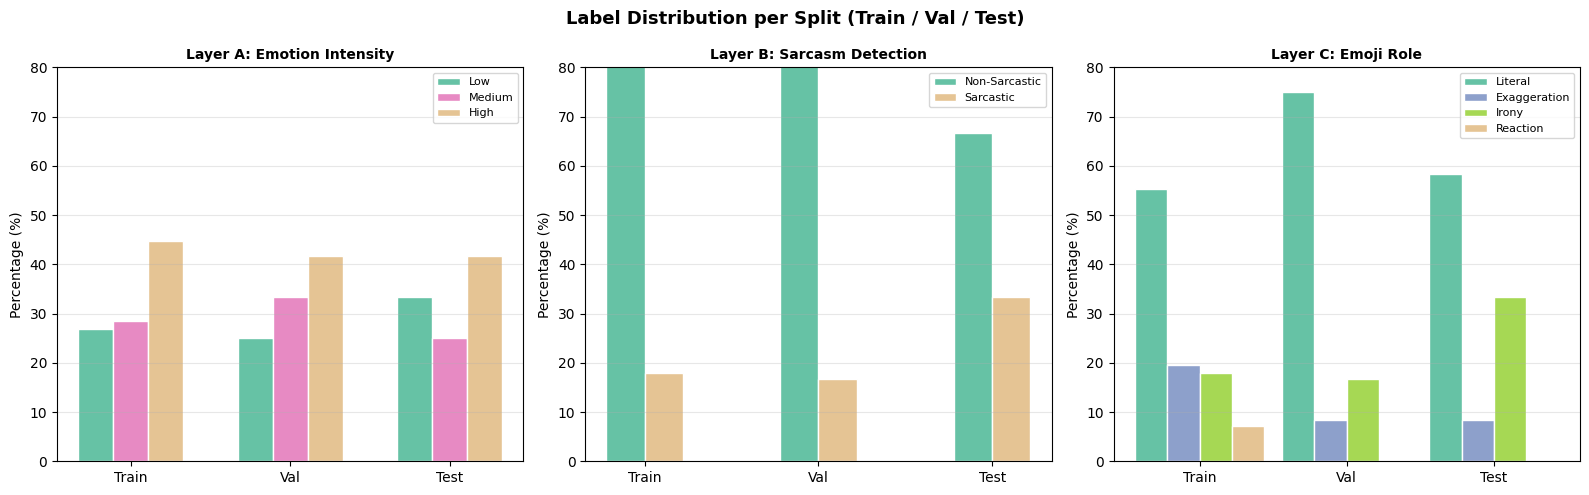

Figure saved: /content/drive/MyDrive/EPGT_Research/outputs/figures/split_label_balance.png


In [20]:
# ============================================================
# CELL 5.5 — Visualisasi Label Balance per Split
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Label Distribution per Split (Train / Val / Test)", fontsize=13, fontweight="bold")

split_dfs   = {"Train": df_train, "Val": df_val, "Test": df_test}
split_colors= {"Train": "#2196F3", "Val": "#4CAF50", "Test": "#FF9800"}

configs = [
    ("label_intensity",   ["Low", "Medium", "High"],              "Layer A: Emotion Intensity"),
    ("label_sarcasm",     ["Non-Sarcastic", "Sarcastic"],          "Layer B: Sarcasm Detection"),
    ("label_emoji_role",  ["Literal", "Exaggeration", "Irony", "Reaction"], "Layer C: Emoji Role"),
]

x         = np.arange(3)  # Train, Val, Test
bar_width = 0.22

for ax, (col, label_names, title) in zip(axes, configs):
    n_labels  = len(label_names)
    offsets   = np.linspace(-(n_labels-1)/2, (n_labels-1)/2, n_labels) * bar_width
    colors    = plt.cm.Set2(np.linspace(0, 0.8, n_labels))

    for i, label in enumerate(label_names):
        values = [
            (df_split[col] == i).sum() / len(df_split) * 100
            for df_split in [df_train, df_val, df_test]
        ]
        ax.bar(x + offsets[i], values, bar_width, label=label, color=colors[i], edgecolor="white")

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(["Train", "Val", "Test"])
    ax.set_ylabel("Percentage (%)")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 80)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
balance_fig_path = DRIVE_ROOT / "outputs/figures/split_label_balance.png"
plt.savefig(str(balance_fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved: {balance_fig_path}")

---
## BAGIAN 6 — NB02 COMPLETION REPORT

In [21]:
# ============================================================
# CELL 6.1 — NB02 Completion Report
# ============================================================

import pandas as pd
import json
from pathlib import Path

print("=" * 60)
print("NB02 COMPLETION REPORT")
print("EPGT Research — Annotation Management & Dataset Split")
print("=" * 60)

print("\n[1] ANNOTATION")
ann_path = DRIVE_ROOT / "data/annotated/final/annotated_final.csv"
if ann_path.exists():
    df_check = pd.read_csv(ann_path)
    print(f"  OK  annotated_final.csv  : {len(df_check):,} samples")
    print(f"       Columns             : {list(df_check.columns)}")
else:
    print("  MISSING  annotated_final.csv")

print("\n[2] INTER-ANNOTATOR AGREEMENT")
iaa_path = DRIVE_ROOT / "data/annotated/final/iaa_report.json"
if iaa_path.exists():
    with open(iaa_path) as f:
        iaa = json.load(f)
    for layer_name, summary in iaa["summary"].items():
        status = "PASS" if summary["meets_threshold"] else "FAIL"
        print(f"  [{status}] {layer_name:<22}: κ = {summary['avg_kappa']:.4f}")
else:
    print("  MISSING  iaa_report.json")

print("\n[3] DATASET SPLIT")
for split_name, fname in [("Train", "train.csv"), ("Val", "val.csv"), ("Test", "test.csv")]:
    path = DRIVE_ROOT / "data/processed" / fname
    if path.exists():
        n = len(pd.read_csv(path))
        print(f"  OK  {fname:<12}: {n:>7,} samples")
    else:
        print(f"  MISSING  {fname}")

print("\n[4] SOURCE FILES")
src_files = ["src/data/annotator.py", "src/data/splitter.py"]
for f in src_files:
    exists = (DRIVE_ROOT / f).exists()
    print(f"  {'OK' if exists else 'MISSING':>7}  {f}")

print("\n[5] NEXT STEP")
print("  → NB03: Data Preprocessing & Emoji Graph Construction")
print("    Preprocessing 7-stage pipeline + graph G=(V,E,W) construction.")
print("\n" + "=" * 60)

NB02 COMPLETION REPORT
EPGT Research — Annotation Management & Dataset Split

[1] ANNOTATION
  OK  annotated_final.csv  : 80 samples
       Columns             : ['id', 'text', 'cleaned_text', 'emoji_sequence', 'emoji_count', 'emoji_density', 'label_intensity', 'label_sarcasm', 'label_emoji_role', 'platform', 'timestamp']

[2] INTER-ANNOTATOR AGREEMENT
  [PASS] Emotion Intensity     : κ = 0.9105
  [PASS] Sarcasm Detection     : κ = 1.0000
  [PASS] Emoji Role            : κ = 0.8047

[3] DATASET SPLIT
  OK  train.csv   :      56 samples
  OK  val.csv     :      12 samples
  OK  test.csv    :      12 samples

[4] SOURCE FILES
       OK  src/data/annotator.py
       OK  src/data/splitter.py

[5] NEXT STEP
  → NB03: Data Preprocessing & Emoji Graph Construction
    Preprocessing 7-stage pipeline + graph G=(V,E,W) construction.

